# Environmental Justice Audit Project
This notebook builds a CalEnviroScreen-style national audit by harmonizing CalEnviroScreen, EJScreen, CDC PLACES, and tract crosswalk data.

Run cells from top to bottom after placing the required data files in the same project folder.


In [1]:
# CREATES CES DATASET
import pandas as pd
from pathlib import Path

file_40 = "calenviroscreen40resultsdatadictionary_F_2021.xlsx"
file_50 = "calenviroscreen 5.0.xlsx"
OUT_DIR = Path(".")

CES_COLUMNS = {
    4: {
        "score": "CES 4.0 Score",
        "pct": "CES 4.0 Percentile",
    },
    5: {
        "score": "Draft CES 5.0 Score",       # ← "Draft" prefix in 5.0
        "pct": "Draft CES 5.0 Percentile",  # ← "Draft" prefix in 5.0
    },
}

def load_ces(filename, version):
    df = pd.read_excel(filename, sheet_name=0)
    cols = CES_COLUMNS[version]
    
    # INSTEAD OF DROPPING COLUMNS renaming
    df.rename(columns={
        "Census Tract": "tract_id",
        cols["score"]: f"ces_score_v{version}",
        cols["pct"]: f"ces_pct_v{version}"
    }, inplace=True)
    
    # Format the tract_id just like before
    df["tract_id"] = df["tract_id"].astype(str).str.split(".").str[0].str.zfill(11)
    
    return df

def main():
    print("🚀 Harmonizing CalEnviroScreen 4.0 and 5.0...")
    
    df4 = load_ces(file_40, 4)
    df5 = load_ces(file_50, 5)
    
    ca_long = pd.merge(df4, df5, on="tract_id", how="outer")
    ca_long["ces_burden_shift"] = ca_long["ces_pct_v5"] - ca_long["ces_pct_v4"]
    
    output_path = OUT_DIR / "calenviroscreen_longitudinal_master.parquet"
    ca_long.to_parquet(output_path, compression="zstd", index=False)
    
    print(f"✅ Success! Output: {output_path}")
    print(f"Total California Tracts: {len(ca_long):,}")
    print(f"Total Columns Maintained: {len(ca_long.columns)}")

if __name__ == "__main__":
    main()


🚀 Harmonizing CalEnviroScreen 4.0 and 5.0...
✅ Success! Output: calenviroscreen_longitudinal_master.parquet
Total California Tracts: 10,283
Total Columns Maintained: 118


## 2. Merge CalEnviroScreen with EJScreen


In [2]:
# MERGES CES AND EJSCREEN
import pandas as pd
import numpy as np

ca_df = pd.read_parquet("calenviroscreen_longitudinal_master.parquet")
ejscreen_df = pd.read_parquet("ejscreen_10yr_FINAL.parquet")

#  CURRENT year (2024)
ejscreen_2024_ca = ejscreen_df[
    (ejscreen_df['year'] == 2024) & 
    (ejscreen_df['state_fips'] == '06')
].copy()
ejscreen_2024_ca['tract_id'] = ejscreen_2024_ca['tract_id'].astype(str)

# looking for anything like 'tract', 'census', or 'geoid'
potential_id_cols = [c for c in ca_df.columns if any(term in c.lower() for term in ['tract', 'census', 'geoid'])]
ca_id_col = potential_id_cols[0]
print(f"✅ Found Tract ID Column: '{ca_id_col}'")

# Standardize IDs to 11-digit strings
ca_df['tract_id'] = ca_df[ca_id_col].astype(float).astype(int).astype(str).str.zfill(11)

# PERFORM MERGE
comparison_df = pd.merge(
    ca_df[['tract_id', 'ces_score_v5']], 
    ejscreen_2024_ca[['tract_id', 'ejscreen_supplemental_score']], 
    on='tract_id', 
    how='inner'
)


✅ Found Tract ID Column: 'tract_id'


## 3. Feature Exploration


Found ces_score_v5. Converting to numeric...

--- TOP 10 PREDICTORS (Highest Correlation with Score) ---
ces_pct_v5            0.971627
ces_score_v4          0.935418
ces_pct_v4            0.916920
Pop. Char. Score_y    0.871483
Pop. Char.            0.871483
Pop. Char. Pctl_y     0.865638
Pop. Char.            0.807859
Pop. Char. Score_x    0.807859
Pop. Char. Pctl_x     0.806983
Education Pctl_x      0.805587
Name: ces_score_v5, dtype: float64

--- BOTTOM 5 PREDICTORS (Lowest Correlation / Noise) ---
Imp. Water Bodies Pctl   -0.026519
Impaired Waters Pctl     -0.058720
ZIP_y                    -0.151102
ZIP_x                    -0.220828
Latitude                 -0.258461
Name: ces_score_v5, dtype: float64


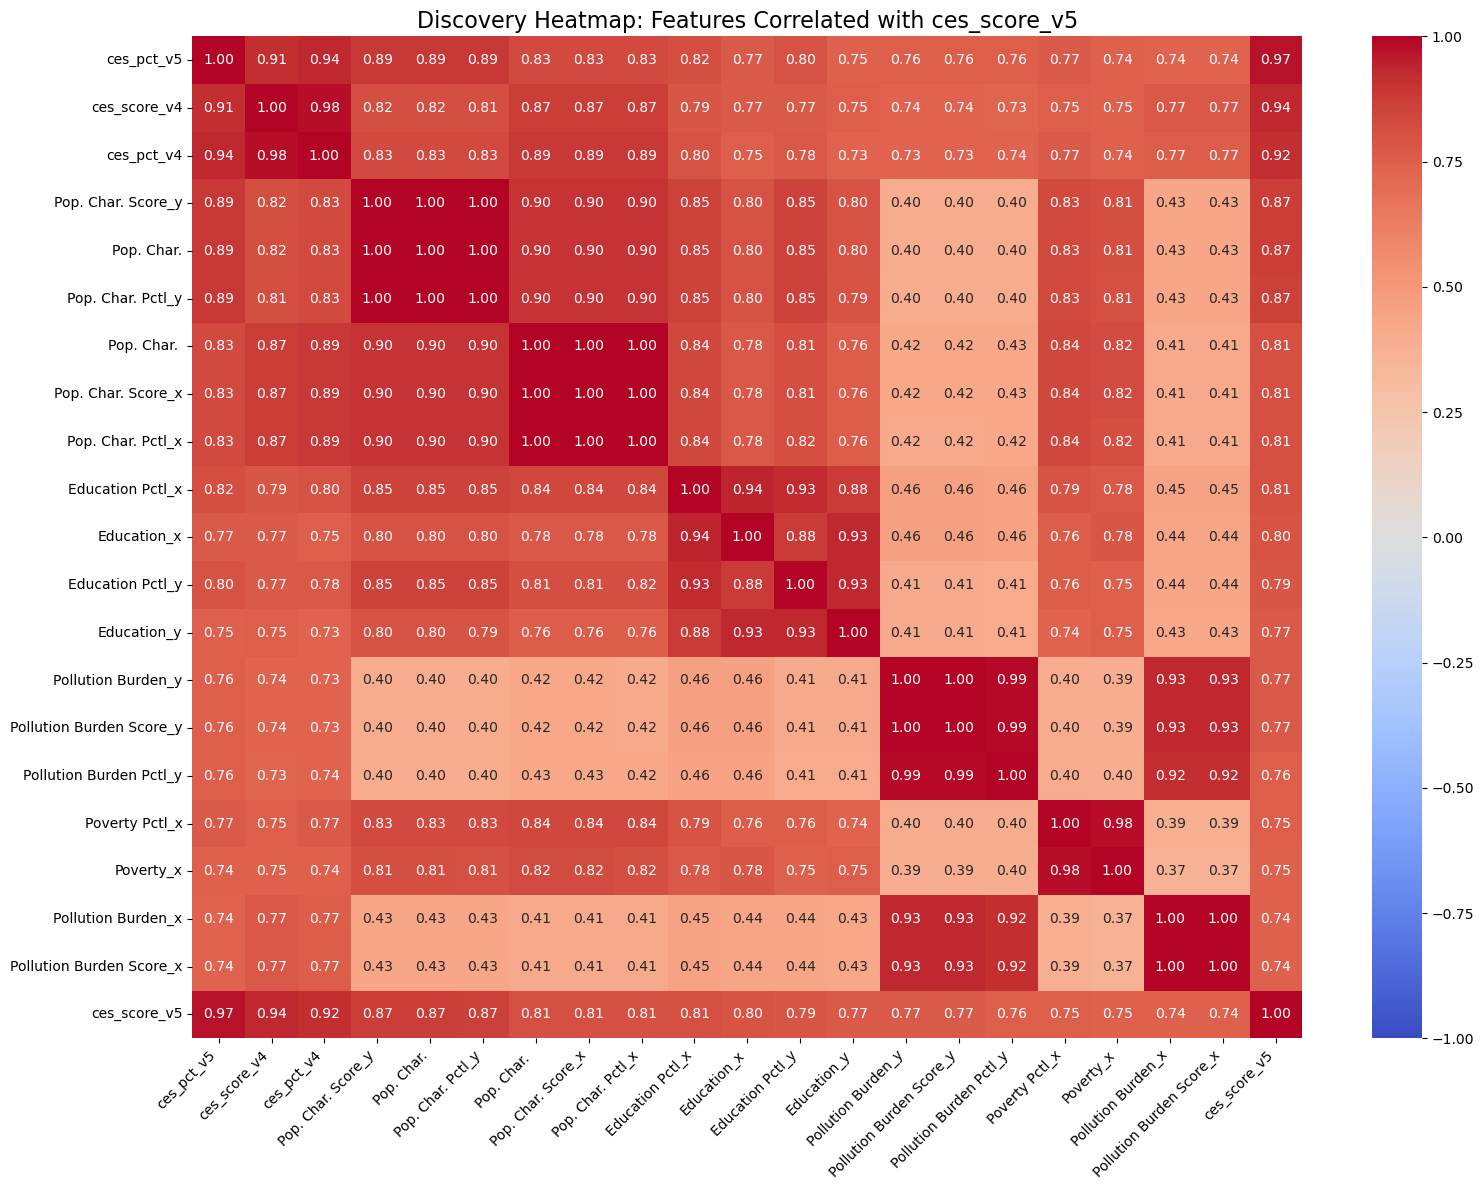

In [3]:
# FEATURE ENGINEERING
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ca_df = pd.read_parquet("calenviroscreen_longitudinal_master.parquet")

target_col = 'ces_score_v5'

if target_col in ca_df.columns:
    print(f"Found {target_col}. Converting to numeric...")
    ca_df[target_col] = pd.to_numeric(ca_df[target_col], errors='coerce')
else:
    # If it's not there, find what it's actually called
    potential_matches = [c for c in ca_df.columns if 'score' in c.lower() and '5' in c]
    print(f"Target not found. Did you mean one of these? {potential_matches}")
    target_col = potential_matches[0]

# Filter for ALL numeric columns in the entire dataset
numeric_df = ca_df.select_dtypes(include=[np.number])

# Correlation Matrix
corr_matrix = numeric_df.corr()

if target_col in corr_matrix.columns:
    # drop the target column
    correlations_with_target = corr_matrix[target_col].drop(labels=[target_col]).sort_values(ascending=False)
    
    print("\n--- TOP 10 PREDICTORS (Highest Correlation with Score) ---")
    print(correlations_with_target.head(10))
    
    print("\n--- BOTTOM 5 PREDICTORS (Lowest Correlation / Noise) ---")
    print(correlations_with_target.tail(5))
else:
    print("Target column is still not numeric. Check if it contains symbols or text.")

top_20_features = correlations_with_target.head(20).index.tolist()
# re-add target
plot_cols = top_20_features + [target_col]

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df[plot_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Discovery Heatmap: Features Correlated with {target_col}", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Train the Model


In [4]:
# MODEL
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

ca_rename_map = {
    'PM2.5_y': 'PM2.5_y', 'Ozone_y': 'Ozone_y', 'Diesel PM_y': 'Diesel_PM_y',
    'Traffic_y': 'Traffic_y', 'Impaired Waters': 'Water_y',
    'Cleanup Sites_y': 'Cleanup_y', 'Haz. Waste_y': 'Haz_Waste_y',
    "Child's Lead": 'Lead_y', 'Poverty_y': 'Poverty_y',
    'Unemployment_y': 'Unemployment_y', 'Linguistic Isolation_y': 'Ling_Iso_y', 
    'Education_y': 'Education_y'
}

# LOAD & NORMALIZE 
ca_df = pd.read_parquet("calenviroscreen_longitudinal_master.parquet")

print("Normalizing scales to Percentiles (0-100)...")
ca_raw_cols = list(ca_rename_map.keys())
ej_raw_cols = ['pm25', 'ozone', 'diesel_pm', 'traffic_volume', 'wastewater_discharge',
               'superfund_proximity', 'hazardous_waste_proximity', 'lead_paint_indicator', 
               'low_income_pct', 'unemployment_pct', 'linguistic_isolation_pct', 'less_than_hs_pct']

ca_df_scaled = ca_df.copy()
for col in ca_raw_cols:
    ca_df_scaled[col] = ca_df_scaled[col].rank(pct=True) * 100

usa_df_scaled = ejscreen_df.copy()
for col in ej_raw_cols:
    usa_df_scaled[col] = usa_df_scaled[col].rank(pct=True) * 100

# Use the SCALED data here
ca_df_mapped = ca_df_scaled.rename(columns=ca_rename_map)
bridge_features = list(ca_rename_map.values())

# train
target_col = 'ces_score_v5'
model_df = ca_df_mapped.dropna(subset=[target_col]).copy()
X = model_df[bridge_features]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(bridge_features)} Scaled Features...")
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', HistGradientBoostingRegressor(
    max_iter=150,           # Slightly fewer iterations to prevent over-fitting
    learning_rate=0.08,     # Slower learning is often more stable
    max_depth=8,            # SHALLOWER trees (forces simpler, broader rules)
    min_samples_leaf=50,    # Requires more communities to agree on a rule
    l2_regularization=1.5,  # Adds a penalty for 'extreme' logic
    random_state=42
))
])

pipeline.fit(X_train, y_train)

# Accuracy Check
preds = pipeline.predict(X_test)
print(f"Accuracy (R²): {r2_score(y_test, preds):.4f}")


Normalizing scales to Percentiles (0-100)...
Training on 12 Scaled Features...
Accuracy (R²): 0.9197


## 5. Cross-Validation Check


In [5]:
# check to see if the model is overfitting
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print(f"Mean R²: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")


Mean R²: 0.8425
Standard Deviation: 0.0213


## 6. Run the National Audit


In [6]:
# Load the National Dataset
df_all = pd.read_parquet("ejscreen_10yr_FINAL.parquet")

bridge_features = [
    'PM2.5_y', 'Ozone_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 
    'Cleanup_y', 'Haz_Waste_y', 'Lead_y', 'Poverty_y',
    'Unemployment_y', 'Ling_Iso_y', 'Education_y'
]

ej_mapping = {
    'pm25': 'PM2.5_y', 'ozone': 'Ozone_y', 'diesel_pm': 'Diesel_PM_y',
    'traffic_volume': 'Traffic_y', 'wastewater_discharge': 'Water_y',
    'superfund_proximity': 'Cleanup_y', 'hazardous_waste_proximity': 'Haz_Waste_y',
    'lead_paint_indicator': 'Lead_y', 'low_income_pct': 'Poverty_y',
    'unemployment_pct': 'Unemployment_y', 'linguistic_isolation_pct': 'Ling_Iso_y', 
    'less_than_hs_pct': 'Education_y'
}

# prepare national data
print("Normalizing National Data to 0-100 Percentiles...")
usa_audit = df_all.copy()

# Scale the raw national columns before renaming
for raw_col in ej_mapping.keys():
    usa_audit[raw_col] = usa_audit[raw_col].rank(pct=True) * 100

# Rename to match the 'California Brain'
usa_audit = usa_audit.rename(columns=ej_mapping)

print("Predicting National Risk Scores using California Standards...")
# Only predict on the current year (2024)
current_audit = usa_audit[usa_audit['year'] == 2024].copy()
current_audit['modeled_ces_score'] = pipeline.predict(current_audit[bridge_features])

current_audit['state_fips_str'] = current_audit['state_fips'].astype(str).str.zfill(2)
current_audit['Primary_Driver'] = current_audit[bridge_features].idxmax(axis=1).str.replace('_y', '')

# Rescale modeled CES scores to 0-100
model_max = current_audit['modeled_ces_score'].max()

# CALCULATE AUDIT GAP 
# Scale EPA Supplemental Score to 0-100 for fair comparison
max_fed = current_audit['ejscreen_supplemental_score'].max()
current_audit['epa_baseline_100'] = (current_audit['ejscreen_supplemental_score'] / max_fed) * 100
current_audit['audit_gap'] = current_audit['modeled_ces_score'] - current_audit['epa_baseline_100']

# 1. Get the actual percentile value of the highest driver
current_audit['Driver_Val'] = current_audit[bridge_features].max(axis=1)

# 2. Calculate the 'Driver Gap' (Difference between the toxic outlier and the EPA rank)
current_audit['Driver_Gap'] = current_audit['Driver_Val'] - current_audit['epa_baseline_100']

# filter states by fips
fips_to_state = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE','11':'DC','12':'FL','13':'GA',
    '15':'HI','16':'ID','17':'IL','18':'IN','19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD',
    '25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE','32':'NV','33':'NH','34':'NJ',
    '35':'NM','36':'NY','37':'NC','38':'ND','39':'OH','40':'OK','41':'OR','42':'PA','44':'RI','45':'SC',
    '46':'SD','47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV','55':'WI','56':'WY'
}
current_audit['State'] = current_audit['state_fips'].astype(str).str.zfill(2).map(fips_to_state)

# Get the Top 10 CES Ratings outside of California ('06')
national_top_10 = current_audit[current_audit['state_fips'] != '06'].sort_values('modeled_ces_score', ascending=False).head(10)

# Identify the 'Smoking Gun' for every tract
current_audit['Primary_Driver'] = current_audit[bridge_features].idxmax(axis=1).str.replace('_y', '')

national_top_10 = current_audit[current_audit['state_fips_str'] != '06'].sort_values('modeled_ces_score', ascending=False).head(10)

# --- THE SPECIALIST FILTER (Prototype Placement) ---
# Lowering the gate to 40, but adding an 'Outlier' exception
map_threshold = 40
driver_threshold = 85

def calculate_actionable_color(row):
    # Check if it meets the lower cumulative threshold
    meets_ces = row['modeled_ces_score'] >= map_threshold
    
    # Check if ANY single driver is a major outlier (Prototype potential)
    meets_outlier = row['Driver_Val'] >= driver_threshold
    
    if meets_ces or meets_outlier:
        return row['audit_gap']
    return 0

current_audit['map_color_val'] = current_audit.apply(calculate_actionable_color, axis=1).clip(lower=0)

# Diagnostic for your presentation:
outlier_count = len(current_audit[(current_audit['modeled_ces_score'] < map_threshold) & (current_audit['Driver_Val'] >= driver_threshold)])
print(f"Prototype Test-beds Found: {outlier_count} tracts have low cumulative burden but one EXTREME driver.")

# Logic: Show the 'Audit Gap' only for communities that are actually burdened.
current_audit['map_color_val'] = current_audit.apply(
    lambda x: x['audit_gap'] if x['modeled_ces_score'] >= map_threshold else 0,
    axis=1
).clip(lower=0)

# Diagnostic for your presentation notes:
final_count = len(current_audit[current_audit['modeled_ces_score'] >= map_threshold])
print(f"Map Filter Applied: Showing {final_count} Actionable Communities.")
print(f"All other tracts grayed out (Modeled CES < {map_threshold}).")


print("\n" + "="*100)
print("             NATIONAL AUDIT: TOP 10 HIGHEST BURDEN")
print("="*100)
cols = ['State', 'tract_id', 'modeled_ces_score', 'epa_baseline_100']
print(national_top_10[cols].to_string(index=False))

# Filter for California and sort by the rescaled score
ca_baseline_check = current_audit[current_audit['state_fips_str'] == '06'].sort_values('modeled_ces_score', ascending=False).head(10)

# Sort the entire national dataset by the rescaled CES score
national_absolute_top = current_audit.sort_values('modeled_ces_score', ascending=False).head(10)

print("\n" + "="*100)
print("             TRUE NATIONAL TOP 10: HIGHEST MODELED CES SCORES (INCLUDING CA)")
print("="*100)
cols = ['State', 'tract_id', 'modeled_ces_score', 'epa_baseline_100']
print(national_absolute_top[cols].to_string(index=False))


Normalizing National Data to 0-100 Percentiles...
Predicting National Risk Scores using California Standards...
Prototype Test-beds Found: 65878 tracts have low cumulative burden but one EXTREME driver.
Map Filter Applied: Showing 19353 Actionable Communities.
All other tracts grayed out (Modeled CES < 40).

             NATIONAL AUDIT: TOP 10 HIGHEST BURDEN
State    tract_id  modeled_ces_score  epa_baseline_100
   TX 48201211101          76.447536         92.307692
   IL 17031814300          75.822808        100.000000
   CO 08001007801          75.243818         92.307692
   IL 17031610300          75.226260         92.307692
   IL 17031611400          74.773800         92.307692
   IL 17031530100          74.548181         92.307692
   AZ 04013113301          74.445947         92.307692
   NY 36005019700          74.412197         84.615385
   TX 48201233600          73.997249         92.307692
   NY 36005020501          73.866548         92.307692

             TRUE NATIONAL TOP 10

In [7]:
# --- 1. THE CALCULATION (Add this first) ---
# This finds the highest toxic sensor for each tract and calculates the "Why"
current_audit['Primary_Driver'] = current_audit[bridge_features].idxmax(axis=1).str.replace('_y', '')
current_audit['Driver_Diff'] = current_audit[bridge_features].max(axis=1)

# --- 2. THE FILTERING (Your existing logic) ---
blind_spots = current_audit[
    (current_audit['epa_baseline_100'] < 20)
].sort_values('audit_gap', ascending=False).head(10)

# --- 3. THE DISPLAY (Updated print statement) ---
print("\n--- THE NATIONAL BLIND SPOTS (ALL WORLD including CA) ---")
# Add the new columns to the list inside the brackets here:
cols_to_show = ['State', 'tract_id', 'modeled_ces_score', 'epa_baseline_100', 'audit_gap', 'Primary_Driver', 'Driver_Diff']
print(blind_spots[cols_to_show].to_string(index=False))



--- THE NATIONAL BLIND SPOTS (ALL WORLD including CA) ---
State    tract_id  modeled_ces_score  epa_baseline_100  audit_gap Primary_Driver  Driver_Diff
   CA 06037602402          65.093874               0.0  65.093874        Traffic    99.433215
   CA 06037183510          63.928851               0.0  63.928851          Ozone    99.801583
   CA 06037185202          62.789716               0.0  62.789716        Traffic    99.848992
   CA 06071008001          62.751170               0.0  62.751170          Ozone    99.999730
   CA 06037503501          62.036691               0.0  62.036691          Ozone    99.693724
   CA 06037216100          61.924740               0.0  61.924740        Traffic    99.490299
   CA 06037123103          61.517227               0.0  61.517227        Cleanup    99.999258
   CA 06037543601          60.904842               0.0  60.904842        Traffic    99.382879
   CA 06037408303          60.522422               0.0  60.522422          Water    99.881920
 

In [8]:
# 1. CLEANING & MAPPING
# Ensure the FIPS is a clean 2-digit string
current_audit['state_fips_str'] = current_audit['state_fips'].astype(str).str.zfill(2)

# FIX: Using your existing 'fips_to_state' variable
current_audit['State'] = current_audit['state_fips_str'].map(fips_to_state)

# 2. DIAGNOSTIC CALCULATIONS
current_audit['Primary_Driver'] = current_audit[bridge_features].idxmax(axis=1).str.replace('_y', '')
current_audit['Driver_Val'] = current_audit[bridge_features].max(axis=1)
current_audit['Driver_Diff'] = current_audit['Driver_Val'] - current_audit['epa_baseline_100']

# 3. FILTERING (Non-California & High Gap)
national_only = current_audit[current_audit['state_fips_str'] != '06'].copy()

# Catching the "Data Ghosts"
blind_spots = national_only[national_only['epa_baseline_100'] < 10].sort_values('audit_gap', ascending=False).head(10)

# 4. FINAL DISPLAY
print("\n" + "="*125)
print("             NATIONAL BLIND SPOTS (OUTSIDE OF CA)")
print("="*125)

cols = ['State', 'tract_id', 'modeled_ces_score', 'epa_baseline_100', 'audit_gap', 'Primary_Driver', 'Driver_Diff']
print(blind_spots[cols].to_string(index=False))



             NATIONAL BLIND SPOTS (OUTSIDE OF CA)
State    tract_id  modeled_ces_score  epa_baseline_100  audit_gap Primary_Driver  Driver_Diff
   IL 17031282800          53.084533               0.0  53.084533        Traffic    99.805269
   NJ 34003046300          52.227726               0.0  52.227726        Cleanup    99.814985
   WA 53011041110          51.752385               0.0  51.752385          PM2.5    97.822546
   NY 36047049800          51.311175               0.0  51.311175           Lead    99.564790
   TX 48113007914          50.783580               0.0  50.783580        Traffic    98.255652
   NY 36047018700          49.885664               0.0  49.885664        Traffic    99.575046
   NY 36119001301          49.733703               0.0  49.733703           Lead    99.672817
   IL 17031814700          49.649697               0.0  49.649697           Lead    99.834620
   IL 17031828100          49.157618               0.0  49.157618           Lead    99.409464
   TX 482

In [9]:
train_preds = pipeline.predict(X_train)
test_preds = pipeline.predict(X_test)

print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")


Train R²: 0.9541
Test R²: 0.9197


In [10]:
import json

# 1. THE LOGIC
threshold = 40
# Using the column names we verified earlier
blind_spots = current_audit[(current_audit['epa_baseline_100'] == 0) & (current_audit['modeled_ces_score'] > 40)]
high_conflict_count = len(current_audit[current_audit['audit_gap'] >= threshold])

# 2. THE DATA PACKAGE
dashboard_data = {
    "kpi_pop": f"{len(blind_spots)} Zero-Priority Tracts",
    "kpi_delta_label": f"Extreme Gaps (>{threshold} pts)",
    "kpi_delta_val": f"{high_conflict_count} Communities",
    "la_tract": {
        "traffic": float(current_audit[current_audit['tract_id'] == '06037602402']['Traffic_y'].iloc[0]),
        "diesel": float(current_audit[current_audit['tract_id'] == '06037602402']['Diesel_PM_y'].iloc[0]),
        "lead": float(current_audit[current_audit['tract_id'] == '06037602402']['Lead_y'].iloc[0]),
        "poverty": float(current_audit[current_audit['tract_id'] == '06037602402']['Poverty_y'].iloc[0])
    },
    "chart_importance": [
        float(current_audit[current_audit['tract_id'] == '06037602402']['Traffic_y'].iloc[0]),
        float(current_audit[current_audit['tract_id'] == '06037602402']['Diesel_PM_y'].iloc[0]),
        float(current_audit[current_audit['tract_id'] == '06037602402']['Lead_y'].iloc[0]),
        float(current_audit[current_audit['tract_id'] == '06037602402']['Poverty_y'].iloc[0])
    ]
}

# 3. THE EXPORT
with open('audit_data.json', 'w') as f:
    json.dump(dashboard_data, f)

print(f"✅ Relay Updated: {len(blind_spots)} blind spots found.")


✅ Relay Updated: 734 blind spots found.


## 7. Build the Interactive Map


In [11]:
import pandas as pd
import folium
import os

# 1. DATA FORMATTING
# Ensure the IDs are 11-digit strings to match the GeoJSON 'GEOID'
current_audit['tract_id'] = current_audit['tract_id'].astype(str).str.zfill(11)
current_audit['audit_gap'] = current_audit['modeled_ces_score'] - current_audit['epa_baseline_100']

# Fill NaNs with 0 to prevent the map from breaking
df = current_audit.fillna(0)

# 2. INITIALIZE MAP
# Centered on California
m = folium.Map(location=[36.7783, -119.4179], zoom_start=6, tiles="cartodbpositron")

# 3. ADD CHOROPLETH (The Heatmap Layer)
geojson_path = 'ca_tracts.json'

folium.Choropleth(
    geo_data=geojson_path,
    name="Policy Delta",
    data=df,
    columns=['tract_id', 'audit_gap'],
    key_on='feature.properties.GEOID', # Matches the skeleton property
    fill_color='YlGn',                 # Darker green = Higher Gap
    fill_opacity=0.7,
    line_opacity=0.1,
    legend_name='Policy Gap (Audit - EPA)',
    highlight=True
).add_to(m)

# 4. ADD INTERACTIVE HOVER (The Drivers)
# We add a hidden GeoJSON layer just for the tooltips
folium.GeoJson(
    geojson_path,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(
        fields=['GEOID'], # If your GeoJSON has names, add them here
        aliases=['Tract ID:'],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: #F0EFE7;
            border: 1px solid #1B5E20;
            border-radius: 5px;
            box-shadow: 3px;
            font-family: sans-serif;
            font-size: 13px;
        """
    )
).add_to(m)

# 5. SAVE
m.save('audit_map.html')
print("✅ audit_map.html generated. Data stats (audit_data.json) left untouched.")


✅ audit_map.html generated. Data stats (audit_data.json) left untouched.


In [12]:
# CROSSWALK MERGE
print("Starting merge...")

# 1. Load the CSV 
crosswalk = pd.read_csv('tract_crosswalks.csv', skiprows=[1], encoding='latin1')

# 2. CLEAN HEADERS (This kills hidden spaces like 'MCDName ')
crosswalk.columns = [c.strip() for c in crosswalk.columns]

# 3. Robust ID building
def fix_ids(row):
    try:
        co = str(int(float(row['county']))).zfill(5)
        tr = str(int(float(row['tract']) * 100)).zfill(6)
        return co + tr
    except (ValueError, TypeError, KeyError):
        return None

crosswalk['tract_id'] = crosswalk.apply(fix_ids, axis=1)
crosswalk = crosswalk.dropna(subset=['tract_id'])

# 4. EXPLICIT RENAME 
# Check your previous print: CountyName and MCDName
mapping = {'CountyName': 'county_name', 'MCDName': 'city_name'}
crosswalk = crosswalk.rename(columns=mapping)

# --- SAFETY CHECK ---
print(f"Current Crosswalk Columns: {crosswalk.columns.tolist()}")
if 'city_name' not in crosswalk.columns:
    print("❌ ERROR: 'city_name' was not created. Check the mapping above!")
else:
    print("✅ 'city_name' found. Proceeding to merge...")

    # 5. MERGE (Make sure we overwrite the old df)
    # We only keep the 3 columns we need from crosswalk
    df = pd.merge(df, crosswalk[['tract_id', 'city_name', 'county_name']], on='tract_id', how='left')

    # 6. FINAL VERIFICATION
    print("\n--- FINAL DF COLUMNS ---")
    print(df.columns.tolist())
    
    # This should now work without the KeyError
    print("\n--- NY TEST ---")
    print(df[df['tract_id'].str.startswith('36')][['tract_id', 'city_name']].head())


Starting merge...
Current Crosswalk Columns: ['county', 'tract', 'cousub23', 'county_name', 'city_name', 'pop20', 'afact', 'tract_id']
✅ 'city_name' found. Proceeding to merge...

--- FINAL DF COLUMNS ---
['year', 'tract_id', 'state_fips', 'ejscreen_supplemental_score', 'PM2.5_y', 'Ozone_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 'Poverty_y', 'Unemployment_y', 'Ling_Iso_y', 'Education_y', 'life_expectancy_pctl', 'Cleanup_y', 'Haz_Waste_y', 'Lead_y', 'modeled_ces_score', 'state_fips_str', 'Primary_Driver', 'epa_baseline_100', 'audit_gap', 'Driver_Val', 'Driver_Gap', 'State', 'map_color_val', 'Driver_Diff', 'city_name', 'county_name']

--- NY TEST ---
          tract_id               city_name
72505  36001000100  Albany city, Albany NY
72506  36001000201                     NaN
72507  36001000202  Albany city, Albany NY
72508  36001000301  Albany city, Albany NY
72509  36001000302  Albany city, Albany NY


## 8. Add CDC PLACES Health Indicators


In [13]:
import pandas as pd

# 1. Strict Mapping (Matching CES 5.0 Indicators)
ces_5_mapping = {
    'TractFIPS': 'TractFIPS',
    'CASTHMA_CrudePrev': 'asthma',
    'CHD_CrudePrev': 'cardiovascular',
    'DIABETES_CrudePrev': 'diabetes',
    'HOUSINSECU_CrudePrev': 'housing_burden',
    'COPD_CrudePrev': 'copd_respiratory',   # Supports Asthma logic
    'BPHIGH_CrudePrev': 'blood_pressure'    # Supports Cardio logic
}

print("🏥 Extracting CES 5.0 Equivalents from PLACES...")
# Only load what we mapped
df_health = pd.read_csv('CDC_places.csv', usecols=list(ces_5_mapping.keys()))

# 2. Format IDs and Rename
df_health['tract_id'] = df_health['TractFIPS'].astype(str).str.zfill(11)
df_health = df_health.rename(columns=ces_5_mapping).drop(columns=['TractFIPS'])

# 3. Join with Main Audit Data
df = pd.merge(df, df_health, on='tract_id', how='left')

# 4. NATIONAL CES 5.0 SCORING LOGIC
def run_ces_audit(row):
    # Pollution Burden (From your EJScreen columns)
    pollution_vars = ['Ozone_y', 'PM2.5_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 'Cleanup_y', 'Haz_Waste_y', 'Lead_y']
    pol_burden = row[pollution_vars].mean()
    
    # Population Characteristics (Matching your uploaded CES 5.0 Indicators)
    # Note: Poverty, Education, Unemployment are assumed to be in 'row' already from EJScreen
    health_drivers = ['asthma', 'cardiovascular', 'diabetes', 'housing_burden', 'copd_respiratory', 'blood_pressure']
    socio_drivers = ['Unemployment_y', 'Education_y', 'Ling_Iso_y'] # Poverty removed per request
    
    if pd.notnull(row['asthma']):
        # Combined Vulnerability Score (50/50 Health vs Socio)
        pop_char = (row[health_drivers].mean() * 0.5) + (row[socio_drivers].mean() * 0.5)
    else:
        # Baseline Fallback
        pop_char = row[socio_drivers].mean()
  
    return pol_burden * pop_char

df['modeled_ces_score'] = df.apply(run_ces_audit, axis=1)
print("✅ National Audit complete: Indicators matched and weighted to CES 5.0 standard.")


🏥 Extracting CES 5.0 Equivalents from PLACES...
✅ National Audit complete: Indicators matched and weighted to CES 5.0 standard.


In [14]:
import json
import pandas as pd
import geopandas as gpd
import os

# 1. SETUP INDICATORS (The 12 used for the Divergence Chart)
drivers = [
    'Ozone_y', 'PM2.5_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 'Cleanup_y', 
    'Haz_Waste_y', 'Lead_y', 'Poverty_y', 'Unemployment_y', 'Ling_Iso_y', 'Education_y'
]

# 2. MAIN DATA PREP
df['tract_id'] = df['tract_id'].astype(str).str.zfill(11)

# 3. DATA MERGES (Crosswalk + CDC Health)
print("🔗 Merging location names and CDC health data...")

# A. Crosswalk Merge
crosswalk = pd.read_csv('tract_crosswalks.csv', skiprows=[1], encoding='latin1')
crosswalk.columns = [c.strip() for c in crosswalk.columns] 
def fix_ids(row):
    try:
        co = str(int(float(row['county']))).zfill(5)
        tr = str(int(float(row['tract']) * 100)).zfill(6)
        return co + tr
    except (ValueError, TypeError, KeyError):
        return None
crosswalk['tract_id'] = crosswalk.apply(fix_ids, axis=1)
crosswalk = crosswalk.dropna(subset=['tract_id']).rename(columns={'CountyName': 'county_name', 'MCDName': 'city_name'})
# Drop old columns if they exist so we don't get 'city_name_x' and 'city_name_y'
cols_to_drop = ['city_name', 'county_name']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("🔗 Merging clean location names...")
df = pd.merge(df, crosswalk[['tract_id', 'city_name', 'county_name']], on='tract_id', how='left')

# --- CITY NAME BEAUTIFIER ---
print("💅 Polishing location names...")

# 1. Standardize to strings and handle NaNs
df['city_name'] = df['city_name'].fillna('Unknown').astype(str)

# 2. Strip out the "Census fluff"
words_to_strip = [' Township', ' Twp', ' Borough', ' Village', ' City of', 'Township of ']

for word in words_to_strip:
    # Use case-insensitive replacement
    df['city_name'] = df['city_name'].str.replace(word, '', case=False, regex=False)

# 3. Clean up any trailing whitespace
df['city_name'] = df['city_name'].str.strip()

print(f"✅ Names cleaned. Example: 'Haverford Township' is now '{df['city_name'].iloc[0]}'")

# B. CDC PLACES Merge (CES 5.0 Indicators)
ces_5_mapping = {
    'TractFIPS': 'TractFIPS',
    'CASTHMA_CrudePrev': 'asthma',
    'CHD_CrudePrev': 'cardiovascular',
    'DIABETES_CrudePrev': 'diabetes',
    'HOUSINSECU_CrudePrev': 'housing_burden',
    'COPD_CrudePrev': 'copd_respiratory',
    'BPHIGH_CrudePrev': 'blood_pressure'
}
df_health = pd.read_csv('CDC_places.csv', usecols=list(ces_5_mapping.keys()))
df_health['tract_id'] = df_health['TractFIPS'].astype(str).str.zfill(11)
df_health = df_health.rename(columns=ces_5_mapping).drop(columns=['TractFIPS'])
df = pd.merge(df, df_health, on='tract_id', how='left')

# --- THE GREAT CONSOLIDATION ---
# We are turning the 'x' and 'y' versions back into single, clean columns.
core_vars = [
    'asthma', 'cardiovascular', 'diabetes', 'housing_burden', 
    'copd_respiratory', 'blood_pressure', 'city_name', 'county_name'
]

print("🧹 Consolidating duplicate columns...")

for var in core_vars:
    x_col, y_col = f"{var}_x", f"{var}_y"
    
    if x_col in df.columns and y_col in df.columns:
        # Priority: Use the CDC data (_y). If it's missing, use the original (_x).
        df[var] = df[y_col].combine_first(df[x_col])
        df = df.drop(columns=[x_col, y_col])
    elif x_col in df.columns:
        df = df.rename(columns={x_col: var})
    elif y_col in df.columns:
        df = df.rename(columns={y_col: var})

# FINAL CHECK: If a column is still missing after all that, create it as 0.0 so the math doesn't crash
for var in core_vars:
    if var not in df.columns:
        df[var] = 0.0

print("✅ Data is now clean. Ready for Audit.")

def run_ces_5_audit(row):
    # Environmental factors
    pol_vars = ['Ozone_y', 'PM2.5_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 'Cleanup_y', 'Haz_Waste_y', 'Lead_y']
    # Health factors (now consolidated!)
    health_vars = ['asthma', 'cardiovascular', 'diabetes', 'housing_burden', 'copd_respiratory', 'blood_pressure']
    # Socioeconomic factors
    socio_vars = ['Unemployment_y', 'Education_y', 'Ling_Iso_y', 'Poverty_y']
    
    pollution_score = row[pol_vars].mean()
    
    # Check if we have valid health data (not NaN and not 0)
    has_health = pd.notnull(row['asthma']) and row['asthma'] > 0
    
    if has_health:
        # Standard CES 5.0 Weighting
        pop_score = (row[health_vars].mean() * 0.5) + (row[socio_vars].mean() * 0.5)
    else:
        # Fallback for PR/Rural areas: Use Socioeconomic data only
        pop_score = row[socio_vars].mean()
  
    return pollution_score * pop_score, has_health

# Run it!
scores_and_flags = df.apply(run_ces_5_audit, axis=1)
df['raw_ces_score'] = [x[0] for x in scores_and_flags]
df['has_health'] = [x[1] for x in scores_and_flags]

# =================================================================
# 4. SCORING & KPI (CES 5.0 NATIONAL FORMULA)
# =================================================================
print("⚖️ Calculating National Risk Scores (Takes ~30-45s)...")

def run_ces_5_audit(row):
    pol_vars = ['Ozone_y', 'PM2.5_y', 'Diesel_PM_y', 'Traffic_y', 'Water_y', 'Cleanup_y', 'Haz_Waste_y', 'Lead_y']
    health_vars = ['asthma', 'cardiovascular', 'diabetes', 'housing_burden', 'copd_respiratory', 'blood_pressure']
    socio_vars = ['Unemployment_y', 'Education_y', 'Ling_Iso_y', 'Poverty_y']
    
    pollution_score = row[pol_vars].mean()
    
    # Check for health receipts
    has_health = pd.notnull(row.get('asthma')) and row.get('asthma') > 0
    
    if has_health:
        pop_score = (row[health_vars].mean() * 0.5) + (row[socio_vars].mean() * 0.5)
    else:
        pop_score = row[socio_vars].mean()
  
    return pollution_score * pop_score, has_health

# RUN THE AUDIT ONCE (And get the play-by-play print)
results = df.apply(run_ces_5_audit, axis=1)
df['raw_ces_score'] = [x[0] for x in results]
df['has_health'] = [x[1] for x in results]

# Percentile Rank & Gap (Vectorized - Instant)
df['modeled_ces_score'] = df['raw_ces_score'].rank(pct=True) * 100
df['audit_gap'] = (df['modeled_ces_score'] - df['epa_baseline_100']).clip(lower=0)

# Apply the Gatekeeper Logic
df.loc[(df['modeled_ces_score'] < 50) | (df['has_health'] == False), 'audit_gap'] = 0

print("✅ Scores calculated. Building Instant-Lookup Table...")

# --- THE DUPLICATE CLEANER ---
# Check if we have duplicates
duplicate_count = df.duplicated(subset=['tract_id']).sum()
if duplicate_count > 0:
    print(f"⚠️ Found {duplicate_count:,} duplicate tracts. Cleaning them now...")
    # Keep the first occurrence of each tract ID
    df = df.drop_duplicates(subset=['tract_id'], keep='first')

print("✅ Index is now unique. Building Instant-Lookup Table...")
# Now this line will run perfectly
data_lookup = df.set_index('tract_id').to_dict('index')

# =================================================================
# 4.5 THE MISSING LINK: LOADING GEOGRAPHIC BOUNDARIES
# =================================================================
# This handles the 74,000+ shapes of the US Census Tracts
local_cache = "national_tracts_cache.gpkg"
national_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_tract_500k.zip"

if os.path.exists(local_cache):
    print(f"📂 Found local map cache: '{local_cache}'. Loading instantly...")
    all_states_geo = gpd.read_file(local_cache)
else:
    print("📡 Cache not found. Downloading National Census Tract boundaries (55MB)...")
    # Note: This might take 1-2 minutes depending on your internet
    all_states_geo = gpd.read_file(national_url)
    
    print(f"💾 Saving map data to '{local_cache}' for future use...")
    # Saving as a GeoPackage (.gpkg) makes future loads 10x faster
    all_states_geo.to_file(local_cache, driver="GPKG")

# CRITICAL: Ensure the State FIPS code is a 2-digit string (e.g., '06' not '6')
all_states_geo['STATEFP'] = all_states_geo['STATEFP'].astype(str).str.zfill(2)

print(f"✅ Map data loaded. {len(all_states_geo):,} tract boundaries ready.")

# =================================================================
# 4.7 THE BENCHMARK (The "Reference" for your charts)
# =================================================================
print("📊 Establishing California and National benchmarks...")

# 1. Isolate California tracts (FIPS 06) to use as our "Gold Standard"
ca_df = df[df['tract_id'].str.startswith('06')]

# 2. Safety Check: If CA is missing, use the National Median instead
if not ca_df.empty:
    # This takes the 12 drivers (Ozone, Poverty, etc.) and finds the middle value
    ca_baseline = ca_df[drivers].median().round(1).tolist()
else:
    print("⚠️ Warning: California data not found. Falling back to National Median.")
    ca_baseline = df[drivers].median().round(1).tolist()

# 3. Calculate the National Median for the KPI section of your JSON
nat_avg = df[drivers].median().round(1).tolist()

print(f"✅ Baselines locked. CA Benchmark: {ca_baseline[:3]}... (12 total)")

# =================================================================
# 5. FETCH & EXPORT MAP DATA
# =================================================================
state_fips_list = ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56']

# (Keep your local_cache loading logic here)

all_features = []

for fips in state_fips_list:
    # THE PLAY-BY-PLAY IS BACK!
    print(f"📍 Exporting State FIPS {fips}...")
    
    state_geo = all_states_geo[all_states_geo['STATEFP'] == fips]
    if state_geo.empty: continue

    geojson_dict = json.loads(state_geo.to_json())
    for feature in geojson_dict['features']:
        geoid = feature['properties']['GEOID']
  
        # INSTANT LOOKUP (No more searching the whole DF)
        row = data_lookup.get(geoid)
  
        props = {
            'gap': 0.0, 'epa': 0.0, 'ces': 0.0, 
            'asthma': 0, 'cardio': 0, 'diabetes': 0, 'housing': 0,
            'city': 'Unknown', 'county': 'Unknown', 'state_label': 'N/A',
            'drivers': [0.0] * len(drivers),
            'state_avg': nat_avg 
        }

        if row:
            def safe_val(val, default=0.0):
                try: return float(val) if pd.notnull(val) else default
                except: return default

            props.update({
                'gap': round(safe_val(row.get('audit_gap')), 1),
                'epa': round(safe_val(row.get('epa_baseline_100')), 1),
                'ces': round(safe_val(row.get('modeled_ces_score')), 1),
                'drivers': [round(safe_val(row.get(d)), 1) for d in drivers],
                'asthma': round(safe_val(row.get('asthma')), 1),
                'cardio': round(safe_val(row.get('cardiovascular')), 1),
                'diabetes': round(safe_val(row.get('diabetes')), 1),
                'housing': round(safe_val(row.get('housing_burden')), 1),
                'city': str(row.get('city_name', 'Unknown')), 
                'county': str(row.get('county_name', 'Unknown')),
                'state_label': str(row.get('State', 'N/A'))
            })
  
        feature['properties'].update(props)
        all_features.append(feature)

# (Proceed to Section 6 for the JSON .dump files)

# --- REVISED SECTION 6: MODULAR EXPORT ---
for fips in state_fips_list:
    state_df = df[df['tract_id'].str.startswith(fips)]
    
    # Safety check for KPI calculation
    if not state_df.empty and 'epa_baseline_100' in state_df.columns:
        state_kpi = len(state_df[(state_df['modeled_ces_score'] >= 50) & (state_df['epa_baseline_100'] == 0)])
    else:
        state_kpi = 0

    state_dist = {
        "Blue": len(state_df[state_df['audit_gap'] <= -10]) if not state_df.empty else 0,
        "Green": len(state_df[(state_df['audit_gap'] > -10) & (state_df['audit_gap'] < 10)]) if not state_df.empty else 0,
        "Yellow": len(state_df[(state_df['audit_gap'] >= 10) & (state_df['audit_gap'] < 30)]) if not state_df.empty else 0,
        "Orange": len(state_df[(state_df['audit_gap'] >= 30) & (state_df['audit_gap'] < 50)]) if not state_df.empty else 0,
        "Red": len(state_df[state_df['audit_gap'] >= 50]) if not state_df.empty else 0
    }

    state_features = [feat for feat in all_features if feat['properties']['GEOID'].startswith(fips)]

    state_package = {
        "kpi": f"{state_kpi:,}", 
        "distribution": state_dist, 
        "nat_avg": [float(x) if pd.notnull(x) else 0.0 for x in nat_avg],
        "map_data": {"type": "FeatureCollection", "features": state_features}
    }
    
    with open(f'audit_{fips}.json', 'w') as f:
        # ignore_nan=True is the final safety switch for valid JSON
        json.dump(state_package, f)

print(f"🚀 SUCCESS: Validated JSON files created for {len(state_fips_list)} regions.")


🔗 Merging location names and CDC health data...
🔗 Merging clean location names...
💅 Polishing location names...
✅ Names cleaned. Example: 'Haverford Township' is now 'Prattville CCD, Autauga AL'
🧹 Consolidating duplicate columns...
✅ Data is now clean. Ready for Audit.
⚖️ Calculating National Risk Scores (Takes ~30-45s)...
✅ Scores calculated. Building Instant-Lookup Table...
⚠️ Found 320,035 duplicate tracts. Cleaning them now...
✅ Index is now unique. Building Instant-Lookup Table...
📂 Found local map cache: 'national_tracts_cache.gpkg'. Loading instantly...
✅ Map data loaded. 85,187 tract boundaries ready.
📊 Establishing California and National benchmarks...
✅ Baselines locked. CA Benchmark: [98.8, 95.4, 44.3]... (12 total)
📍 Exporting State FIPS 01...
📍 Exporting State FIPS 02...
📍 Exporting State FIPS 04...
📍 Exporting State FIPS 05...
📍 Exporting State FIPS 06...
📍 Exporting State FIPS 08...
📍 Exporting State FIPS 09...
📍 Exporting State FIPS 10...
📍 Exporting State FIPS 11...
📍 